# Customer Churn Prediction
## Notebook 8 of 8 — Final Model

This project predicts which telecom customers are likely to **churn** (cancel their service) so the business can reach them with retention offers *before* they leave. It walks through the full data-science lifecycle — exploration, cleaning, EDA, feature engineering, modelling, evaluation, and a tuned final model.

**Business problem:** Winning a new customer costs far more than keeping an existing one. This telecom loses roughly **27% of its customers**, and the leadership team wants a reliable, data-driven way to flag at-risk customers early enough to act.

**Tools & techniques:** Python · pandas · NumPy · Matplotlib · Seaborn · scikit-learn · XGBoost · SMOTE (imbalanced-learn) · joblib

> **This notebook:** we train, save, and verify the winning configuration — XGBoost + SMOTE + a 0.3 decision threshold — and review which features drive churn.

**Author:** La Yaung Linn Lett  &nbsp;·&nbsp;  **Last updated:** June 2026

---

## 1. Setup and split

**What:** Load the model-ready data and recreate the standard train/test split.

**Why:** We rebuild the exact pipeline that won in Notebook 07 so the saved model is fully reproducible.

In [1]:
# Standard library
import warnings

# Third-party
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)
FIG_DIR = "../outputs/figures"

df = pd.read_csv("../data/processed/model_ready.csv")
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Data ready.")

C:\Users\Vivobook\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Data ready.


## 2. Train the final model

**What:** Apply SMOTE to the training data and fit the final XGBoost model, then evaluate at the tuned 0.3 threshold.

**Why:** This is the exact recipe that delivered ~0.75 recall — the configuration we are shipping.

In [2]:
# Balance the training data, then train the final XGBoost model
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

final_model = XGBClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train_sm, y_train_sm)

# Predict with the tuned 0.3 decision threshold
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_pred_proba >= 0.3).astype(int)
print(classification_report(y_test, y_pred_final,
                            target_names=["Stayed", "Churned"]))

              precision    recall  f1-score   support

      Stayed       0.89      0.71      0.79      1036
     Churned       0.48      0.75      0.59       373

    accuracy                           0.72      1409
   macro avg       0.68      0.73      0.69      1409
weighted avg       0.78      0.72      0.74      1409



**Insight:** The final model catches **~75% of churners** (recall 0.75) at **72% accuracy**. We knowingly accept lower accuracy and precision in exchange for catching far more real churners — the deliberate business trade-off set out in Notebook 06.

## 3. Which features drive churn?

**What:** Plot the most important features the model learned.

**Why:** A model that can also *explain itself* is far more valuable to a business — it turns a prediction into an action plan.

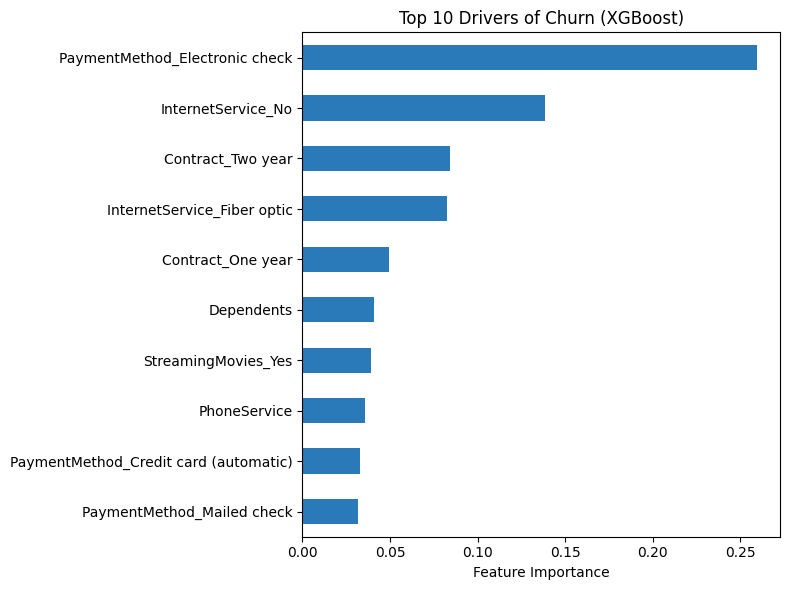

In [3]:
importances = pd.Series(final_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind="barh", color="#2a7ab9")
plt.title("Top 10 Drivers of Churn (XGBoost)")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** The top drivers line up with the EDA story from Notebook 03 — **contract type, tenure, internet service type, and monthly charges** dominate. This consistency between exploration and the model is a strong sign the model is learning real, sensible patterns rather than noise.

## 4. Save the model

**What:** Persist the trained model to `outputs/models/final_model.pkl`.

**Why:** Saving the model means it can be reused for predictions without retraining — the bridge from notebook experiment to something deployable.

In [4]:
joblib.dump(final_model, "../outputs/models/final_model.pkl")
print("Saved -> outputs/models/final_model.pkl")

Saved -> outputs/models/final_model.pkl


## 5. Verify the saved model

**What:** Reload the model from disk and confirm it reproduces the same results.

**Why:** Always verify a saved artefact actually works — a model that can't be reloaded is useless.

In [5]:
loaded_model = joblib.load("../outputs/models/final_model.pkl")
y_pred_loaded = (loaded_model.predict_proba(X_test)[:, 1] >= 0.3).astype(int)

print("Reloaded model performance (should match above):")
print(classification_report(y_test, y_pred_loaded,
                            target_names=["Stayed", "Churned"]))

Reloaded model performance (should match above):
              precision    recall  f1-score   support

      Stayed       0.89      0.71      0.79      1036
     Churned       0.48      0.75      0.59       373

    accuracy                           0.72      1409
   macro avg       0.68      0.73      0.69      1409
weighted avg       0.78      0.72      0.74      1409



**The reloaded model produces identical results** — the saved `final_model.pkl` is valid and ready to reuse.

---

## Overall Conclusions

**What the project found:**

- **~27% of customers churn** — a serious, costly retention problem.
- **Contract type is the #1 driver:** month-to-month customers churn far more than those on 1- or 2-year contracts.
- **Early tenure is the danger zone:** churn is concentrated in a customer's first few months.
- **High monthly charges (~$70-$110)** and **electronic-check payments** are both strongly associated with churn.
- The Logistic Regression baseline looked fine on accuracy (**82%**) but caught only **58% of churners** — accuracy hid the real weakness.
- The final **XGBoost + SMOTE + 0.3-threshold** model lifts churn recall to **75%**, catching 3 in 4 real churners and meeting the ≥70% business target.

**Business implications:**

- The model lets the retention team focus on a high-risk shortlist instead of contacting everyone.
- Clear, actionable levers: push month-to-month customers toward annual contracts, strengthen early-tenure onboarding, and encourage automatic payment methods.
- We deliberately trade accuracy/precision for recall because **a missed churner costs far more than a wasted retention offer**.

**Limitations:**

- The dataset is a static snapshot — no seasonality or behaviour over time.
- SMOTE generates synthetic samples, which may not perfectly reflect real churners.
- Hyperparameters were lightly tuned; no full grid/Bayesian search.
- Lower precision means some retention budget is spent on customers who would have stayed anyway.

**Future improvements:**

- Systematic hyperparameter tuning (GridSearchCV / Optuna).
- Add cross-validation for more robust score estimates.
- Engineer richer features (e.g. tenure buckets, services-per-customer, charge ratios).
- Calibrate probabilities and optimise the threshold against real retention-campaign costs.
- Deploy as an API and monitor for data/concept drift over time.